In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from climbing_analysis.ephys.events import detect_camera_on

In [ ]:
# create data path
project_root = Path.cwd().parent

data_path = project_root / 'examples' / 'sample_data' / 'continuous_event_test_data.npz'

# load test data
data = np.load(data_path)
print(f"Available arrays: {data.files}")

Available arrays ['signal', 'sample_rate', 'camera_fps']


In [ ]:
# create variables
signal = data['signal']
sample_rate = data['sample_rate']
fps = data['camera_fps']

# pad signal snippet
signal_pad = np.pad(signal, 1000, mode='minimum')
_, _, _, fc_df = detect_camera_on(signal_pad, sample_rate, '', frame_rate=fps, min_bout_duration=0.0, save_events=False)

# examine data frame
fc_df.head()

,video_index,frame_id,sample_index
0,0,0,1277
1,0,1,1427
2,0,2,1577


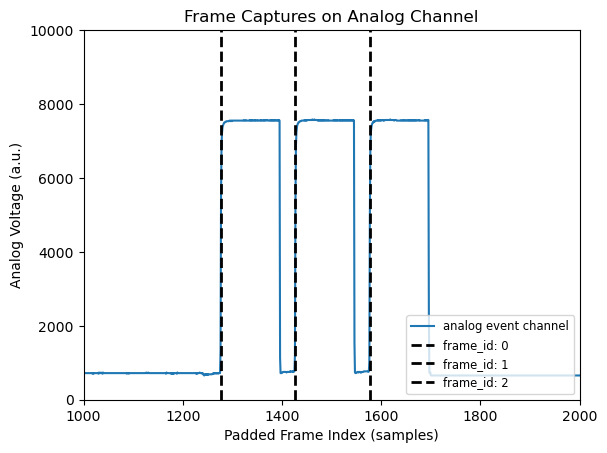

In [34]:
plt.plot(signal_pad,label='analog event channel')
for i, x in enumerate(fc_df['sample_index']):
    plt.axvline(x, linestyle='--', linewidth=2, color='black', label=f'frame_id: {i}')
plt.ylim(0,10000.)
plt.title('Frame Captures on Analog Channel')
plt.xlabel('Padded Frame Index (samples)')
plt.ylabel('Analog Voltage (a.u.)')
plt.xlim([1000,2000])
plt.legend(fontsize='small', loc='lower right')
plt.show()